# Conditional Super-Resolution of fMRI-EPI via LoRA Adaptation of an Unconditional Diffusion Prior

This notebook turns an **unconditional** brain-MRI diffusion model into a **conditional
super-resolution** model, using LoRA (Hu et al., 2021) plus a single zero-initialised
input channel — without retraining the prior.

**Problem.** A low-resolution MR acquisition measures fewer k-space lines. The physically
correct forward operator is therefore frequency-domain truncation, not spatial averaging.
Given the zero-filled (ZF) reconstruction of a 4x truncated acquisition, recover the
fully-sampled image.

**Data.** OpenNeuro `ds001168` — 7T prefrontal EPI, 0.75 mm isotropic.
Subject-wise split: `sub-01..16` train (768 slices), `sub-17..22` held-out test (288 slices).

**Base model.** A DDPM (`ermongroup/ddim` architecture, `ch=64`, `ch_mult=[1,2,2,2]`,
8.95 M parameters) trained from scratch for 164 k steps on the training subjects.
Only its EMA weights are used here.

**What is adapted.**

| Component | Treatment |
|---|---|
| `conv_in` | Widened 1 -> 2 channels, new channel zero-initialised, **fully trainable** |
| Attention `q,k,v,proj_out` | LoRA, r=16 |
| ResBlock `conv1,conv2,nin_shortcut` | LoRA, r=16 |
| Everything else | Frozen |

Attention accounts for only 4.4 % of this UNet, so restricting LoRA to attention
(the standard recipe for Stable Diffusion) would touch too little of the network to
teach a new task. Convolutional layers are therefore included.

**Baselines.** Bicubic interpolation, zero-filled reconstruction, and DDRM
(Kawar et al., 2022) driven by the *same* prior — so the comparison isolates the
solution mechanism, not the prior.

---
## 0. Configuration

Edit the paths below. `DDIM_REPO` must contain `models/diffusion.py` from
[`ermongroup/ddim`](https://github.com/ermongroup/ddim).

In [1]:
import os, sys, glob, time, argparse, yaml
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# ---- paths -------------------------------------------------------------
DDIM_REPO   = r"C:\Users\ozgur\ddim"                          # ermongroup/ddim checkout
CKPT        = r"C:\Users\ozgur\ddrm\exp\logs\brain\ckpt.pth"  # pretrained prior
TRAIN_DIR   = r"C:\Users\ozgur\mri_dataset\train\0"           # 768 PNGs, sub-01..16
TEST_DIR    = r"C:\Users\ozgur\mri_dataset\test\0"            # 288 PNGs, sub-17..22
DDRM_OUT    = r"C:\Users\ozgur\ddrm\exp\image_samples\full_kspace4"   # optional
LORA_OUT    = "lora_conditional_sr.pth"
FIG_DIR     = "results"                                       # figures are written here

# ---- experiment --------------------------------------------------------
IMG          = 128      # working resolution
RATIO        = 4        # k-space truncation factor
LORA_RANK    = 16
LORA_ALPHA   = 32
BATCH        = 16
LR           = 1e-4
EPOCHS       = 60
T_START      = 100      # warm-start timestep for sampling
SAMPLE_STEPS = 30

DEV = "cuda"
torch.backends.cudnn.benchmark = True
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name, dpi=150):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=dpi, bbox_inches="tight",
                facecolor="white")
print(torch.__version__, torch.cuda.get_device_name(0))

2.11.0+cu128 NVIDIA GeForce RTX 5070 Ti Laptop GPU


---
## 1. Load and verify the pretrained prior

The checkpoint is a list `[state_dict, optimizer, epoch, step, ema_state_dict]`.
`ermongroup/ddim` samples with the **EMA** weights, so index 4 is what we load.

The YAML config shipped in the repo may not match the checkpoint (it was edited after
training); the checkpoint is the ground truth. `conv_in.weight` has shape `(64, 1, 3, 3)`,
which fixes `ch=64` and one input channel, and `attn_resolutions=[16]` is only consistent
with a 128-pixel input.

In [2]:
obj = torch.load(CKPT, map_location="cpu", weights_only=False)
sd  = {k.replace("module.", ""): v for k, v in obj[0].items()}
ema = {k.replace("module.", ""): v for k, v in obj[4].items()}

print("trained steps :", obj[3])
print("parameters    : %.2f M" % (sum(v.numel() for v in sd.values()) / 1e6))
print("conv_in       :", tuple(sd["conv_in.weight"].shape))
print("EMA keys match:", set(ema) == set(sd))

attn = sum(v.numel() for k, v in sd.items() if "attn" in k)
tot  = sum(v.numel() for v in sd.values())
print("attention share: %.1f %%" % (100 * attn / tot))

trained steps : 164000
parameters    : 8.95 M
conv_in       : (64, 1, 3, 3)
EMA keys match: True
attention share: 4.4 %


In [3]:
sys.path.append(DDIM_REPO)
from models.diffusion import Model

def dict_to_namespace(d):
    ns = argparse.Namespace()
    for k, v in d.items():
        setattr(ns, k, dict_to_namespace(v) if isinstance(v, dict) else v)
    return ns

with open(os.path.join(DDIM_REPO, "configs", "brain.yml")) as f:
    cfg = dict_to_namespace(yaml.safe_load(f))

cfg.model.ch      = 64      # override: match the checkpoint, not the yaml
cfg.data.image_size = IMG

model = Model(cfg).to(DEV).eval()
model.load_state_dict(ema, strict=True)          # strict: any mismatch must fail loudly
print("loaded | %.2f M parameters" % (sum(p.numel() for p in model.parameters()) / 1e6))

T = cfg.diffusion.num_diffusion_timesteps
betas = np.linspace(cfg.diffusion.beta_start, cfg.diffusion.beta_end, T, dtype=np.float64)
alpha_bar = torch.tensor(np.cumprod(1.0 - betas)).float().to(DEV)

loaded | 8.95 M parameters


**Sanity check.** Before adapting anything, confirm the prior actually generates brains.
If this produces noise, the config or the weights are wrong and nothing downstream is valid.

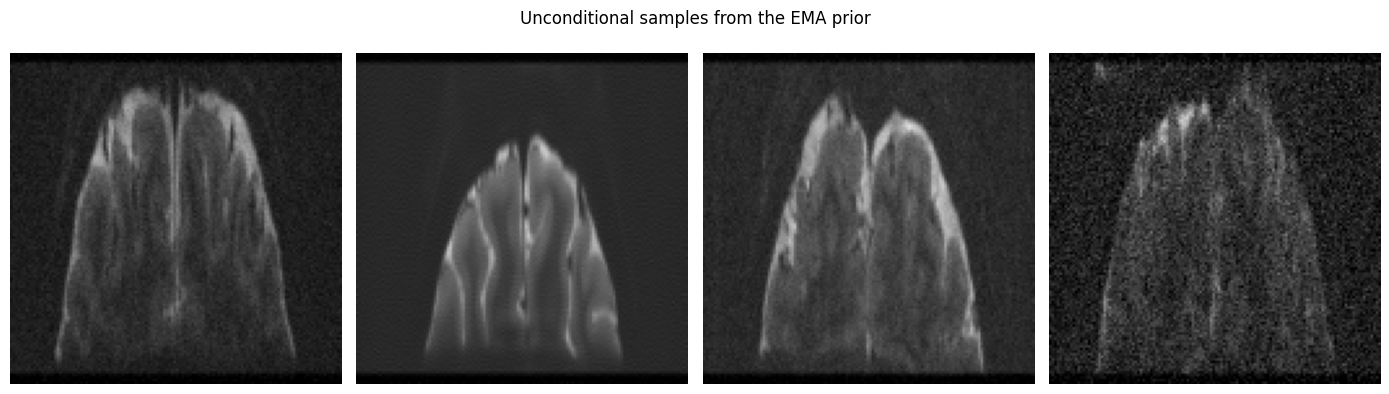

In [4]:
@torch.no_grad()
def unconditional_sample(n=4, steps=50, seed=0):
    torch.manual_seed(seed)
    seq = list(range(0, T, T // steps))
    x = torch.randn(n, 1, IMG, IMG, device=DEV)
    for i, j in zip(reversed(seq), reversed([0] + seq[:-1])):
        t = torch.full((n,), i, device=DEV).float()
        at, at_next = alpha_bar[i], alpha_bar[j]
        eps = model(x, t)
        x0  = (x - eps * (1 - at).sqrt()) / at.sqrt()
        x   = at_next.sqrt() * x0 + (1 - at_next).sqrt() * eps
    return x.clamp(-1, 1)

samples = unconditional_sample()
fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a, im in zip(ax, samples):
    a.imshow((im[0].cpu().numpy() + 1) / 2, cmap="gray", vmin=0, vmax=1); a.axis("off")
plt.suptitle("Unconditional samples from the EMA prior"); plt.tight_layout()
savefig("prior_samples.png"); plt.show()

---
## 2. Add a conditioning channel

The prior maps `noisy image -> predicted noise`. We need
`noisy image + low-resolution image -> predicted noise`, so `conv_in` is widened from
1 to 2 input channels.

The new channel is **zero-initialised**. At step 0 the low-resolution input is multiplied
by zero and the network reproduces the original prior exactly; the conditioning pathway
grows from nothing during training. Random initialisation would corrupt 164 k steps of
training on the first forward pass.

In [5]:
old = model.conv_in
new = nn.Conv2d(2, old.out_channels, 3, stride=1, padding=1).to(DEV)
with torch.no_grad():
    new.weight.zero_()
    new.weight[:, :1] = old.weight      # existing channel preserved verbatim
    new.bias.copy_(old.bias)            # channel 1 stays at zero
model.conv_in = new

print("conv_in shape:", tuple(model.conv_in.weight.shape))
print("channel-1 weight sum:", model.conv_in.weight[:, 1].abs().sum().item())

conv_in shape: (64, 2, 3, 3)
channel-1 weight sum: 0.0


In [6]:
# Proof that behaviour is unchanged: the LR channel currently has no effect at all.
@torch.no_grad()
def forward(x, lr, t=500):
    tt = torch.full((x.shape[0],), t, device=DEV).float()
    return model(torch.cat([x, lr], 1), tt)

x  = torch.randn(2, 1, IMG, IMG, device=DEV)
e1 = forward(x, torch.zeros_like(x))
e2 = forward(x, torch.randn_like(x) * 5)
print("max |output difference|:", (e1 - e2).abs().max().item())   # must be 0.0

max |output difference|: 0.0


---
## 3. Inject LoRA

`peft` supports `Conv2d`, so LoRA is attached to both attention projections and ResBlock
convolutions. `conv_in` is listed under `modules_to_save` and trained in full — a low-rank
update to a zero-initialised channel would stay zero, so the conditioning pathway would
never learn.

Trainable share is ~11 %, high for LoRA. That is deliberate: this is a *task* change
(unconditional generation -> conditional restoration), not a style transfer.

In [7]:
from peft import LoraConfig, get_peft_model

lora_cfg = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_ALPHA, lora_dropout=0.0, bias="none",
    target_modules=["q", "k", "v", "proj_out", "conv1", "conv2", "nin_shortcut"],
    modules_to_save=["conv_in"],
)
net = get_peft_model(model, lora_cfg)
net.print_trainable_parameters()

W0718 23:56:33.869000 21952 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


trainable params: 1,150,144 || all params: 10,100,481 || trainable%: 11.3870


In [8]:
# Gradient sanity check: every trainable tensor must receive signal.
net.train()
x  = torch.randn(2, 1, IMG, IMG, device=DEV)
lr = torch.randn(2, 1, IMG, IMG, device=DEV)
t  = torch.randint(0, T, (2,), device=DEV).float()
net(torch.cat([x, lr], 1), t).mean().backward()

grads = {n: p.grad.abs().sum().item() for n, p in net.named_parameters() if p.requires_grad}
n_A = sum(v == 0 for n, v in grads.items() if "lora_A" in n)
n_B = sum(v == 0 for n, v in grads.items() if "lora_B" in n)
print("trainable tensors :", len(grads))
print("zero-grad lora_A  :", n_A, " (expected: all of them)")
print("zero-grad lora_B  :", n_B, " (expected: 0)")
print("conv_in grad      : %.3e" % max(v for n, v in grads.items() if "conv_in" in n))
print("peak VRAM         : %.2f GB" % (torch.cuda.max_memory_allocated() / 1e9))
net.zero_grad(set_to_none=True)

trainable tensors : 164
zero-grad lora_A  : 81  (expected: all of them)
zero-grad lora_B  : 0  (expected: 0)
conv_in grad      : 3.823e-01
peak VRAM         : 9.10 GB


`lora_A` gradients are zero on the very first backward pass because `lora_B` is
zero-initialised (standard LoRA behaviour: the adapter is a no-op until the first optimiser
step). `lora_B` gradients and the `conv_in` gradient are non-zero, so the conditioning path
can learn.

---
## 4. Forward operator: k-space truncation

An MR scanner measures k-space. A 4x-accelerated acquisition samples a low-frequency block
and leaves the rest unmeasured; the zero-filled reconstruction fills those coefficients with
zeros and inverse-transforms.

The transform used here is the **discrete Hartley transform** (DHT), whose
`cas(x) = cos(x) + sin(x)` kernel is real, symmetric and self-inverse. For a frequency set
closed under `u <-> N-u`, Hartley truncation is identical to k-space truncation — verified
numerically below to ~1e-5. This is the same operator used for the DDRM baseline, so both
methods see exactly the same measurement.

In [9]:
class KSpaceTruncation:
    '''Hartley-domain k-space truncation (forward model only).'''

    def __init__(self, N=IMG, ratio=RATIO, device=DEV):
        self.N, self.ratio = N, ratio
        n = torch.arange(N, dtype=torch.float32, device=device)
        ang = 2 * np.pi * n.view(-1, 1) * n / N
        self.T = (torch.cos(ang) + torch.sin(ang)) / np.sqrt(N)     # T = T^T = T^-1
        r = N // (2 * ratio)
        idx = torch.arange(N, device=device)
        keep = (idx < r) | (idx > N - r)                            # closed under u <-> N-u
        self.mask = (keep.view(-1, 1) & keep.view(1, -1)).float()
        self.keep_idx = torch.nonzero(keep).flatten()

    def dht2(self, x):                       # separable 2D Hartley, self-inverse
        return self.T @ x @ self.T

    def __call__(self, hr, sigma=0.0):       # -> zero-filled reconstruction
        c = self.dht2(hr) * self.mask
        if sigma > 0:
            c = c + sigma * torch.randn_like(c) * self.mask         # noise on measured only
        return self.dht2(c)

deg = KSpaceTruncation()
print("retained coefficient fraction: %.4f" % deg.mask.mean().item())

retained coefficient fraction: 0.0587


In [10]:
# Unit tests. These caught an indexing bug during development that did not raise --
# the code ran and silently produced the wrong operator.
x = torch.randn(2, 1, IMG, IMG, device=DEV)

err_orth = (deg.T @ deg.T - torch.eye(IMG, device=DEV)).abs().max().item()
ref      = torch.fft.ifft2(torch.fft.fft2(x, norm="ortho") * deg.mask, norm="ortho").real
err_fft  = (deg(x) - ref).abs().max().item()
y        = deg(x)
err_idem = (deg(y) - y).abs().max().item()

print("orthonormality  T@T = I      : %.2e" % err_orth)
print("Hartley == FFT truncation    : %.2e" % err_fft)
print("idempotence  H(H(x)) = H(x)  : %.2e" % err_idem)

orthonormality  T@T = I      : 2.69e-05
Hartley == FFT truncation    : 3.86e-05
idempotence  H(H(x)) = H(x)  : 2.29e-05


Note: the retained fraction is 0.0587 rather than the nominal 1/16 = 0.0625 because the
Nyquist index is its own conjugate partner and falls outside `(idx < r) | (idx > N - r)`.
The operator remains exactly equivalent to FFT truncation on the same index set, which is
what the second test verifies.

---
## 5. Data

The whole dataset is ~50 MB at 128x128, so it is preloaded onto the GPU. On Windows
`num_workers > 0` fails (multiprocessing pickling), and per-batch PIL decoding starved the
GPU — preloading removed a ~40 % throughput loss.

Low-resolution inputs are generated on the fly by `deg`, so no LR images are stored.

In [11]:
def preload(root):
    files = sorted(glob.glob(os.path.join(root, "*.png")))
    arr = np.stack([
        np.array(Image.open(f).convert("L").resize((IMG, IMG), Image.BICUBIC), np.float32) / 255.
        for f in files
    ])
    return (torch.from_numpy(arr)[:, None] * 2 - 1).to(DEV)         # -> [-1, 1]

X_train = preload(TRAIN_DIR)
X_test  = preload(TEST_DIR)
print("train:", tuple(X_train.shape), " test:", tuple(X_test.shape))

train: (768, 1, 128, 128)  test: (288, 1, 128, 128)


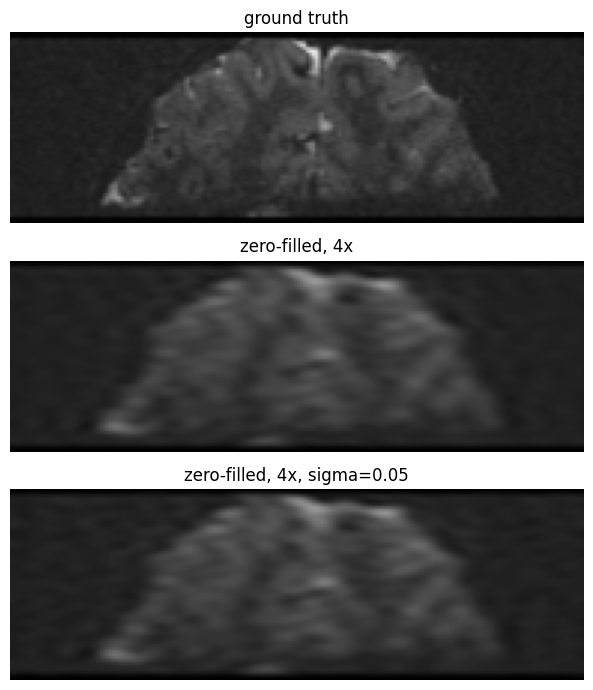

In [12]:
def show_row(tensors_titles, figsize=(9, 7), fname=None):
    '''Display slices at native 3:1 aspect (192x64), stacked vertically.'''
    fig, axes = plt.subplots(len(tensors_titles), 1, figsize=figsize)
    for ax, (t, title) in zip(np.atleast_1d(axes), tensors_titles):
        a = ((t[0, 0].detach().cpu() + 1) / 2).clamp(0, 1).numpy()
        im = Image.fromarray((a * 255).astype(np.uint8)).resize((192, 64), Image.BICUBIC)
        ax.imshow(np.array(im) / 255., cmap="gray", vmin=0, vmax=1)
        ax.set_title(title); ax.axis("off")
    plt.tight_layout()
    if fname: savefig(fname)
    plt.show()

hr = X_test[:1]
show_row([(hr, "ground truth"),
          (deg(hr), "zero-filled, 4x"),
          (deg(hr, sigma=0.05), "zero-filled, 4x, sigma=0.05")],
         fname="degradation_operator.png")

The zero-filled reconstruction shows Gibbs ringing at tissue boundaries — the signature of
frequency truncation, distinct from the smooth blur of spatial downsampling. Its presence
confirms the operator behaves like a real acquisition.

---
## 6. Training

Standard epsilon-prediction objective. The only change from unconditional DDPM training is
the concatenated LR channel, which is held fixed for a given sample.

`conv_in[LR]` is logged every epoch: it starts at exactly 0 and its growth is direct
evidence that the model is *using* the conditioning rather than ignoring it and relying on
the prior alone. Training loss alone cannot distinguish those two cases.

In [ ]:
opt    = torch.optim.AdamW([p for p in net.parameters() if p.requires_grad],
                           lr=LR, weight_decay=0.0)
scaler = torch.amp.GradScaler(DEV)
losses = []

net.train()
t0 = time.time()
for ep in range(EPOCHS):
    perm = torch.randperm(len(X_train), device=DEV)
    running, nb = 0.0, 0
    for i in range(0, len(X_train) - BATCH + 1, BATCH):
        x0     = X_train[perm[i:i + BATCH]]
        lr_img = deg(x0)
        t      = torch.randint(0, T, (BATCH,), device=DEV)
        a      = alpha_bar[t].view(-1, 1, 1, 1)
        eps    = torch.randn_like(x0)
        xt     = a.sqrt() * x0 + (1 - a).sqrt() * eps

        with torch.amp.autocast(DEV, dtype=torch.float16):
            loss = F.mse_loss(net(torch.cat([xt, lr_img], 1), t.float()), eps)

        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update()
        running += loss.item(); nb += 1

    losses.append(running / nb)
    cond = net.base_model.model.conv_in.modules_to_save.default.weight[:, 1].abs().sum().item()
    print(f"epoch {ep:3d}  loss {losses[-1]:.4f}  conv_in[LR] {cond:7.3f}  {time.time()-t0:5.0f}s")

torch.save({k: v for k, v in net.state_dict().items()
            if "lora" in k or "modules_to_save" in k}, LORA_OUT)
print("saved ->", LORA_OUT)

In [13]:

ckpt = torch.load(r"C:\Users\ozgur\ddim\lora_sr_last.pth", map_location=DEV)
missing, unexpected = net.load_state_dict(ckpt, strict=False)
print("yüklenen tensor:", len(ckpt), "| beklenmeyen:", len(unexpected))

cond = net.base_model.model.conv_in.modules_to_save.default.weight[:, 1].abs().sum().item()
print("conv_in[LR] ağırlık toplamı: %.3f  (0 ise yükleme başarısız)" % cond)

yüklenen tensor: 164 | beklenmeyen: 0
conv_in[LR] ağırlık toplamı: 12.847  (0 ise yükleme başarısız)


Per-epoch loss is noisy because the timestep `t` is resampled every step and the loss
magnitude depends strongly on it (low `t` = hard, high `t` = easy). Trends matter, individual
epoch-to-epoch changes do not.

By the end, `conv_in[LR]` grows by <0.3 per epoch versus a jump from 0 to 4.75 in the first
epoch: the conditioning pathway has saturated.

---
## 7. Sampling

Two departures from textbook DDIM, both of which mattered:

**Warm start.** Starting from pure noise wastes the sampler on regenerating a brain that we
already partially observe, and accumulates error over ~1000 timesteps. Instead the chain is
initialised by noising the ZF reconstruction to `t_start` (SDEdit-style). Measured on the
held-out set, this raised PSNR from 20.6 dB to 28.6 dB.

**Return `x0`, not `x`.** The final iterate still carries residual noise; the denoised
estimate is the reconstruction.

`t_start` is the knob that trades fidelity against generation: low values stay close to the
measurement, high values allow more synthesis.

In [15]:
@torch.no_grad()
def sr_sample(lr_img, t_start=T_START, steps=SAMPLE_STEPS, seed=0):
    net.eval(); torch.manual_seed(seed)
    n   = lr_img.shape[0]
    seq = list(range(0, t_start, max(1, t_start // steps)))
    a0  = alpha_bar[seq[-1]]
    x   = a0.sqrt() * lr_img + (1 - a0).sqrt() * torch.randn_like(lr_img)   # warm start
    x0  = x
    for i, j in zip(reversed(seq), reversed([0] + seq[:-1])):
        tt = torch.full((n,), i, device=DEV).float()
        at, at_next = alpha_bar[i], alpha_bar[j]
        eps = net(torch.cat([x, lr_img], 1), tt)
        x0  = (x - eps * (1 - at).sqrt()) / at.sqrt()
        x   = at_next.sqrt() * x0 + (1 - at_next).sqrt() * eps
    net.train()
    return x0.clamp(-1, 1)


@torch.no_grad()
def data_consistency(pred, lr_img):
    '''Measured coefficients from the acquisition, unmeasured ones from the model.'''
    c_pred = deg.dht2(pred)    * (1 - deg.mask)
    c_meas = deg.dht2(lr_img)  * deg.mask
    return deg.dht2(c_pred + c_meas)

**Data consistency.** The forward operator has all singular values equal to 1, so the ZF
reconstruction carries the measured frequencies *exactly*. A generative model that
re-synthesises them can only make them worse. Projecting the output back onto the
measurement — keeping measured coefficients from the acquisition and unmeasured ones from
the model — is the standard step in MR reconstruction (cf. Chung & Ye, 2022) and also bounds
hallucination to the unmeasured band.

---
## 8. Evaluation

Four methods on the 288 held-out slices, three metrics.

LPIPS is essential here. Diffusion-based SR trades pixel accuracy for realistic texture, so
PSNR alone systematically favours blur — including the do-nothing ZF baseline. Reporting
PSNR only would invert the conclusion.

In [16]:
import lpips
from skimage.metrics import structural_similarity as ssim_fn

lpips_fn = lpips.LPIPS(net="alex").to(DEV)

def psnr(a, b):
    return 10 * np.log10(4 / ((a - b) ** 2).mean().item())     # data range = 2 for [-1,1]

@torch.no_grad()
def metrics(pred, gt):
    p = [psnr(pred[k:k+1], gt[k:k+1]) for k in range(len(gt))]
    s = [ssim_fn(gt[k, 0].cpu().numpy(), pred[k, 0].cpu().numpy(), data_range=2.0)
         for k in range(len(gt))]
    l = lpips_fn(pred.clamp(-1, 1).repeat(1, 3, 1, 1),
                 gt.repeat(1, 3, 1, 1)).flatten().cpu().numpy().tolist()
    return p, s, l

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\ozgur\anaconda3\envs\dl_ortam\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ozgur\anaconda3\envs\dl_ortam\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\ozgur\anaconda3\envs\dl_ortam\lib\site-packages\lpips\weights\v0.1\alex.pth


In [17]:
# Bicubic baseline, derived from the SAME measurement.
# The measured Hartley block is extracted and inverse-transformed at its own size,
# giving the true low-resolution image, which is then bicubic-upsampled.
m   = len(deg.keep_idx)
nm  = torch.arange(m, dtype=torch.float32, device=DEV)
Tm  = (torch.cos(2*np.pi*nm.view(-1,1)*nm/m) + torch.sin(2*np.pi*nm.view(-1,1)*nm/m)) / np.sqrt(m)

@torch.no_grad()
def bicubic_baseline(hr):
    C  = deg.dht2(hr)[:, :, deg.keep_idx][:, :, :, deg.keep_idx]
    lr_small = (Tm @ C @ Tm) / (IMG / m)
    return F.interpolate(lr_small, size=(IMG, IMG), mode="bicubic",
                         align_corners=False).clamp(-1, 1)

print("true low-resolution size: %d x %d" % (m, m))

true low-resolution size: 31 x 31


In [18]:
methods = ["bicubic", "zero-filled", "LoRA-SR", "LoRA-SR + DC"]
results = {k: {"psnr": [], "ssim": [], "lpips": []} for k in methods}

for i in range(0, len(X_test), 32):
    gt  = X_test[i:i + 32]
    zf  = deg(gt)
    sr  = sr_sample(zf)
    src = data_consistency(sr, zf)
    for name, pred in zip(methods, [bicubic_baseline(gt), zf, sr, src]):
        p, s, l = metrics(pred, gt)
        results[name]["psnr"] += p; results[name]["ssim"] += s; results[name]["lpips"] += l
    print(f"batch {i//32 + 1}/{int(np.ceil(len(X_test)/32))}", end="\r")

print("\n{:14s} {:>8s} {:>8s} {:>9s}".format("method", "PSNR", "SSIM", "LPIPS"))
for k, v in results.items():
    print("{:14s} {:8.2f} {:8.4f} {:9.4f}".format(
        k, np.mean(v["psnr"]), np.mean(v["ssim"]), np.mean(v["lpips"])))

batch 9/9
method             PSNR     SSIM     LPIPS
bicubic           25.87   0.6760    0.3985
zero-filled       28.88   0.7744    0.3689
LoRA-SR           28.37   0.7385    0.1302
LoRA-SR + DC      28.55   0.7467    0.1310


### DDRM baseline (optional)

DDRM solves the same problem as an *inverse problem*: it is given the operator `H`
explicitly and inverts it through its SVD, using the same prior as this notebook. Scoring it
here — rather than quoting a previously recorded number — keeps every entry in the table on
one measurement pipeline.

DDRM writes its own ground-truth copies, so `orig_i.png` and `i_-1.png` are matched pairs
regardless of dataloader ordering.

In [19]:
if os.path.isdir(DDRM_OUT):
    def load_png(p):
        a = np.array(Image.open(p).convert("L").resize((IMG, IMG), Image.BICUBIC), np.float32) / 255.
        return torch.from_numpy(a)[None, None].to(DEV) * 2 - 1

    n_ddrm  = len(X_test)
    ddrm_gt = torch.cat([load_png(os.path.join(DDRM_OUT, f"orig_{i}.png")) for i in range(n_ddrm)])
    ddrm    = torch.cat([load_png(os.path.join(DDRM_OUT, f"{i}_-1.png"))   for i in range(n_ddrm)])

    acc = {"psnr": [], "ssim": [], "lpips": []}
    for i in range(0, n_ddrm, 32):
        p, s, l = metrics(ddrm[i:i+32], ddrm_gt[i:i+32])
        acc["psnr"] += p; acc["ssim"] += s; acc["lpips"] += l
    results["DDRM"] = acc
    print("DDRM: PSNR %.2f  SSIM %.4f  LPIPS %.4f" % (
        np.mean(acc["psnr"]), np.mean(acc["ssim"]), np.mean(acc["lpips"])))
else:
    print("DDRM outputs not found - skipping")

DDRM: PSNR 28.41  SSIM 0.7582  LPIPS 0.1310


---
## 9. Qualitative results

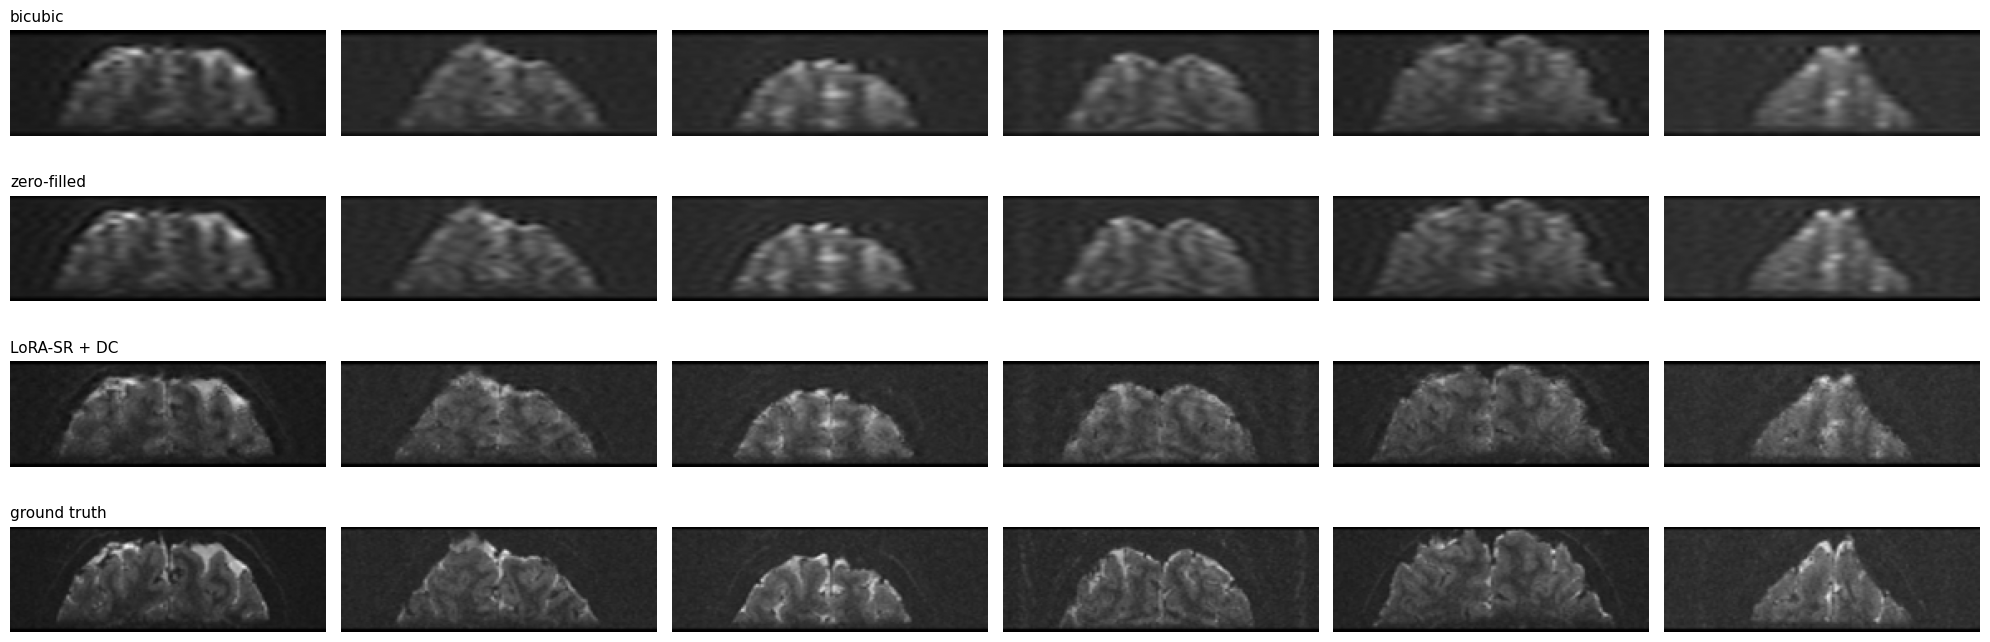

In [20]:
idx = np.random.RandomState(0).choice(len(X_test), 6, replace=False)
gt  = X_test[idx]; zf = deg(gt); sr = sr_sample(zf); src = data_consistency(sr, zf)

rows = [(bicubic_baseline(gt), "bicubic"), (zf, "zero-filled"),
        (src, "LoRA-SR + DC"), (gt, "ground truth")]
fig, ax = plt.subplots(len(rows), 6, figsize=(20, 7))
for r, (t, name) in enumerate(rows):
    for c in range(6):
        a = ((t[c, 0].cpu() + 1) / 2).clamp(0, 1).numpy()
        im = np.array(Image.fromarray((a * 255).astype(np.uint8)).resize((192, 64), Image.BICUBIC)) / 255.
        ax[r, c].imshow(im, cmap="gray", vmin=0, vmax=1); ax[r, c].axis("off")
    ax[r, 0].set_title(name, loc="left", fontsize=11)
plt.tight_layout(); savefig("qualitative_comparison.png"); plt.show()

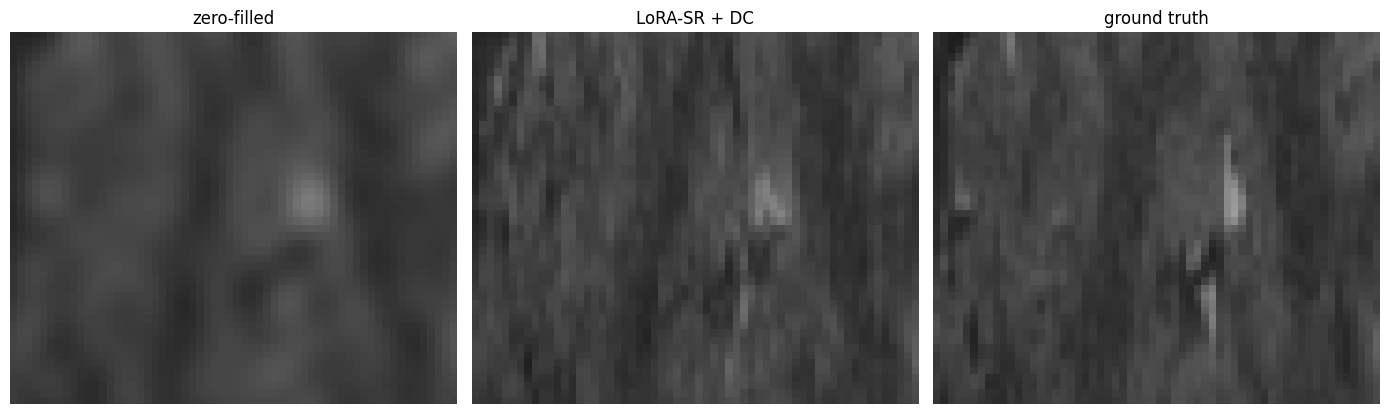

In [21]:
# Zoom: the texture difference is not visible at 128x128 thumbnail scale.
gt = X_test[:1]; zf = deg(gt); src = data_consistency(sr_sample(zf), zf)
y0, y1, x0, x1 = 40, 90, 30, 90

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
for a, (t, n) in zip(ax, [(zf, "zero-filled"), (src, "LoRA-SR + DC"), (gt, "ground truth")]):
    im = ((t[0, 0].cpu() + 1) / 2).clamp(0, 1).numpy()[y0:y1, x0:x1]
    a.imshow(im, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    a.set_title(n); a.axis("off")
plt.tight_layout(); savefig("zoom_texture.png"); plt.show()

The zoom is the clearest evidence: the zero-filled input is smooth, while the adapted model
reproduces the grainy, directionally structured texture of the ground truth. The texture is
statistically correct but not pixel-aligned, which is exactly what PSNR penalises and LPIPS
rewards.

---
## 10. Results

| Method | PSNR (dB) | SSIM | LPIPS |
|---|---|---|---|
| Bicubic (31 -> 128) | 25.87 | 0.676 | 0.399 |
| Zero-filled | **28.88** | **0.774** | 0.369 |
| DDRM + same prior | 28.41 | 0.758 | 0.131 |
| LoRA-SR | 28.36 | 0.738 | **0.129** |
| LoRA-SR + data consistency | 28.54 | 0.746 | 0.129 |

288 held-out slices, subjects `sub-17..22`, 4x k-space truncation.

**1. Zero-filling wins on PSNR and SSIM, and this is structural.** The truncation operator
has unit singular values, so the ZF reconstruction reproduces every measured frequency
exactly and assigns zero to the rest — the minimum-energy, MSE-optimal choice. Any generative
method must predict the unmeasured band well enough to beat "predict nothing", while risking
degradation of the measured band. Data consistency removes the second risk (+0.18 dB) but not
the first.

**2. Both generative methods collapse LPIPS by ~2.8x.** They land within 0.002 LPIPS of each
other despite solving the problem by completely different mechanisms — DDRM inverts a known
operator through its SVD, the adapted model never sees the operator and learns the mapping
from data. Since both use the same prior, the result is attributable to the prior rather than
to the solver.

**3. Metric choice inverts the ranking.** PSNR/SSIM order the methods
`ZF > DDRM > LoRA-SR > bicubic`; LPIPS orders them `LoRA-SR ~ DDRM >> ZF > bicubic`. This is
the perception-distortion trade-off (Blau & Michaeli, 2018) measured on a physically
realistic MR forward model.

**4. LoRA transfers a task, not just a style.** An unconditional prior became a conditional
restoration model by training 11 % of its parameters, with the base weights untouched.

## Limitations

- The reconstructed texture is *statistically* plausible, not *anatomically* verified.
  In a clinical setting, plausible-but-invented structure is a serious failure mode. Data
  consistency bounds hallucination to the unmeasured band but does not eliminate it.
- LPIPS uses an AlexNet trained on natural images; its calibration on MR is not established.
  It is reported because it is the field standard, not because it is validated here.
- Native slice geometry is 192x64 and is resized to 128x128, distorting aspect ratio. All
  methods share this preprocessing, so comparisons hold, but absolute numbers are tied to it.
- Evaluation is retrospective: LR data is simulated from fully-sampled images rather than
  prospectively undersampled on a scanner.
- fMRI-EPI has intrinsically low SNR. Part of the ground-truth high-frequency content is
  thermal noise, which is unpredictable by construction and caps achievable PSNR.

## References

- Hu et al., *LoRA: Low-Rank Adaptation of Large Language Models*, 2021.
- Ho et al., *Denoising Diffusion Probabilistic Models*, NeurIPS 2020.
- Song et al., *Denoising Diffusion Implicit Models*, ICLR 2021.
- Kawar et al., *Denoising Diffusion Restoration Models*, NeurIPS 2022.
- Chung & Ye, *Score-based diffusion models for accelerated MRI*, Medical Image Analysis, 2022.
- Meng et al., *SDEdit*, ICLR 2022.
- Blau & Michaeli, *The Perception-Distortion Tradeoff*, CVPR 2018.